In [5]:
!pip install numpy pandas matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [8]:
df = pd.read_csv("heart.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully!
Shape: (1025, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Dataset Info:
(1025, 14)

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target Distribution:
target
1    526
0    499
Name: count, dtype: int64


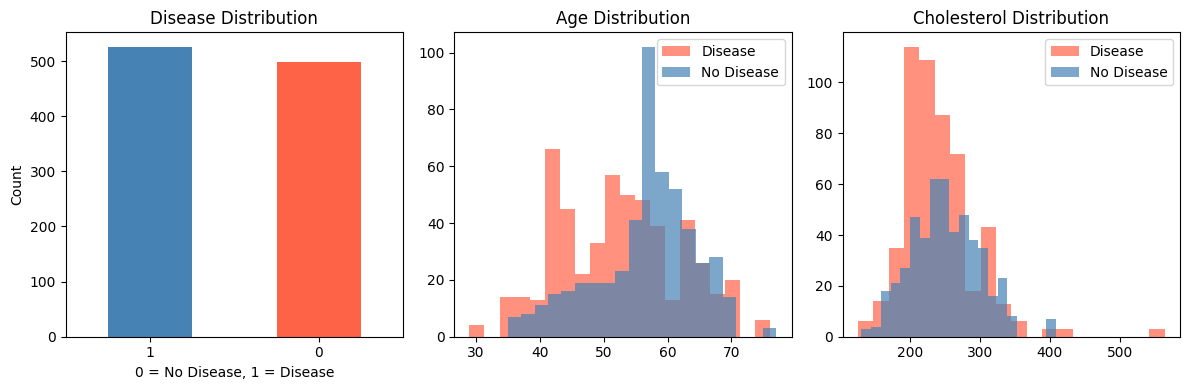

EDA plots displayed successfully!


In [7]:
print("Dataset Info:")
print(df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTarget Distribution:")
print(df['target'].value_counts())

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
df['target'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title("Disease Distribution")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.subplot(1, 3, 2)
plt.hist(df[df['target']==1]['age'], bins=20, alpha=0.7, color='tomato', label='Disease')
plt.hist(df[df['target']==0]['age'], bins=20, alpha=0.7, color='steelblue', label='No Disease')
plt.title("Age Distribution")
plt.legend()

plt.subplot(1, 3, 3)
plt.hist(df[df['target']==1]['chol'], bins=20, alpha=0.7, color='tomato', label='Disease')
plt.hist(df[df['target']==0]['chol'], bins=20, alpha=0.7, color='steelblue', label='No Disease')
plt.title("Cholesterol Distribution")
plt.legend()

plt.tight_layout()
plt.show()
print("EDA plots displayed successfully!")

In [10]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Data preprocessing completed successfully!")

Train size: (820, 13)
Test size: (205, 13)
Data preprocessing completed successfully!


In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, kernel="rbf", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}

results = {}

print(f"{'Model':<25} {'Accuracy':>10} {'AUC':>10}")
print("-" * 50)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {"model": model, "acc": acc, "auc": auc, "y_pred": y_pred, "y_prob": y_prob}
    print(f"{name:<25} {acc:>10.3f} {auc:>10.3f}")

print("-" * 50)
best_name = max(results, key=lambda k: results[k]["auc"])
print(f"\nBest Model: {best_name}(AUC = {results[best_name]['auc']:.4f})")

Model                       Accuracy        AUC
--------------------------------------------------
Logistic Regression            0.810      0.930
Random Forest                  1.000      1.000
Gradient Boosting              0.976      0.988
SVM                            0.927      0.977
KNN                            0.844      0.945
--------------------------------------------------

Best Model: Random Forest(AUC = 1.0000)


In [12]:
best = results[best_name]

print(f"Classification Report - {best_name}:")
print(classification_report(y_test, best["y_pred"], target_names=["No Disease", "Disease"]))

Classification Report - Random Forest:
              precision    recall  f1-score   support

  No Disease       1.00      1.00      1.00       100
     Disease       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



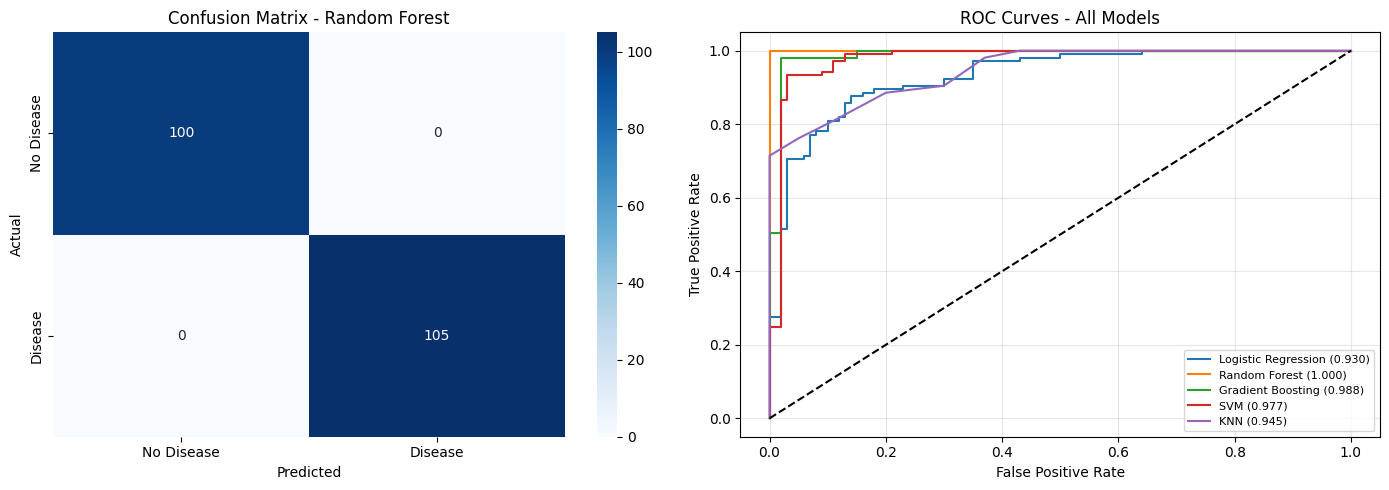

Confusion matrix and ROC curves displayed successfully!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, best["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
axes[0].set_title(f"Confusion Matrix - {best_name}")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ROC Curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    axes[1].plot(fpr, tpr, label=f"{name} ({res['auc']:.3f})")
axes[1].plot([0,1], [0,1], "k--")
axes[1].set_title("ROC Curves - All Models")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Confusion matrix and ROC curves displayed successfully!")

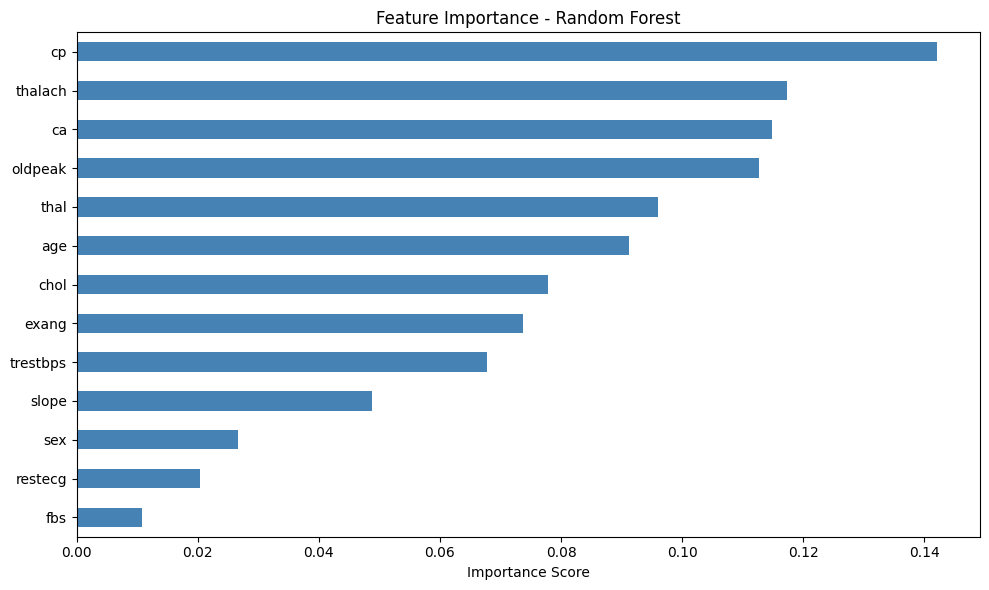

Feature importance displayed successfully!


In [15]:
rf_model = results["Random Forest"]["model"]
feature_importance = pd.Series(rf_model.feature_importances_, index=df.drop("target", axis=1).columns)
feature_importance.sort_values().plot(kind="barh", figsize=(10, 6), color="steelblue")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()
print("Feature importance displayed successfully!")

In [16]:
import pickle

with open("heart_disease_model.pkl", "wb") as f:
    pickle.dump(results["Random Forest"]["model"], f)

print("Model saved successfully!")

Model saved successfully!
